In [1]:
# Try to do conservation scores with PyCanal
# Check here: https://github.com/jafetgado/PyCanal/tree/master
from pycanal import Canal
canal = Canal(fastafile='./DruE3_mmseqs98.MUSCLE5.faa', # Multiple sequence alignment (MSA) of homologous sequences
              ref=161, # Position of reference sequence in MSA, I use ECOR19 as before
              #startcount=-16, # Position label of first residue in reference sequence
              verbose=True # Print out progress
              )
# Compute conservation scores for each site in reference sequence with relative entropy method
cons_scores = canal.analysis(include=None, method='relative')


555 sequences in fasta file

Multiple sequence alignment has 4002 total positions

Reference sequence is WP_020219138.1 MULTISPECIES: DEAD/DEAH box helicase [Enterobacteriaceae]

Reference sequence has 2104 residues (sites) and the first residue is labeled as position 1

Reference sequence residues are labeled as M-1, D-2, V-3, Q-4, Q-5

Calculating amino acid frequencies...
Done.

Calculating conservation scores with relative method...
Done


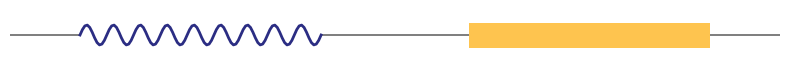

In [2]:
# Extract the secondary structure from PDB

# Modified code from Patrick Kunzmann
# License: BSD 3 clause

#This creates the objects that can be plotted

from tempfile import gettempdir
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import biotite
import biotite.application.dssp as dssp
import biotite.database.entrez as entrez
import biotite.database.rcsb as rcsb
import biotite.sequence as seq
import biotite.sequence.graphics as graphics
import biotite.sequence.io.genbank as gb
import biotite.structure as struc
import biotite.structure.io.pdb as pdb

# Create 'FeaturePlotter' subclasses
# for drawing the scondary structure features


class HelixPlotter(graphics.FeaturePlotter):
    def __init__(self):
        pass

    # Check whether this class is applicable for drawing a feature
    def matches(self, feature):
        if feature.key == "SecStr":
            if "sec_str_type" in feature.qual:
                if feature.qual["sec_str_type"] == "helix":
                    return True
        return False

    # The drawing function itself
    def draw(self, axes, feature, bbox, loc, style_param):
        # Approx. 1 turn per 3.6 residues to resemble natural helix
        n_turns = np.ceil((loc.last - loc.first + 1) / 3.6)
        x_val = np.linspace(0, n_turns * 2 * np.pi, 100)
        # Curve ranges from 0.3 to 0.7
        y_val = (-0.4 * np.sin(x_val) + 1) / 2

        # Transform values for correct location in feature map
        x_val *= bbox.width / (n_turns * 2 * np.pi)
        x_val += bbox.x0
        y_val *= bbox.height
        y_val += bbox.y0

        # Draw white background to overlay the guiding line
        background = Rectangle(
            bbox.p0, bbox.width, bbox.height, color="white", linewidth=0
        )
        axes.add_patch(background)
        axes.plot(x_val, y_val, linewidth=2, color='#2b2d83') # '#dd3497')


class SheetPlotter(graphics.FeaturePlotter):
    def __init__(self, head_width=0.8, tail_width=0.5):
        self._head_width = head_width
        self._tail_width = tail_width

    def matches(self, feature):
        if feature.key == "SecStr":
            if "sec_str_type" in feature.qual:
                if feature.qual["sec_str_type"] == "sheet":
                    return True
        return False

    def draw(self, axes, feature, bbox, loc, style_param):
        x = bbox.x0
        y = bbox.y0 + bbox.height / 2
        dx = bbox.width
        dy = 0
        """
        if loc.defect & seq.Location.Defect.MISS_RIGHT:
            # If the feature extends into the prevoius or next line
            # do not draw an arrow head
            draw_head = False
        else:
            draw_head = True
        """
        axes.add_patch(
            biotite.AdaptiveFancyArrow(
                x,
                y,
                dx,
                dy,
                self._tail_width * bbox.height,
                self._head_width * bbox.height,
                # Create head with 90 degrees tip
                head_ratio=0.4,
                draw_head=False,
                color='#fec44f',
                linewidth=0,
            )
        )

# Test how the drawing functions work with example
annotation = seq.Annotation(
    [
        seq.Feature("SecStr", [seq.Location(10, 40)], {"sec_str_type": "helix"}),
        seq.Feature("SecStr", [seq.Location(60, 90)], {"sec_str_type": "sheet"}),
    ]
)

fig = plt.figure(figsize=(8.0, 0.8))
ax = fig.add_subplot(111)
graphics.plot_feature_map(
    ax,
    annotation,
    multi_line=False,
    loc_range=(1, 100),
    # Register our drawing functions
    feature_plotters=[HelixPlotter(), SheetPlotter()],
)
fig.tight_layout()

In [3]:
## Extract Secondary structure from Predicted AF2 model
# Converter for the DSSP secondary structure elements
# to the classical ones
dssp_to_abc = {
    "I": "c",
    "S": "c",
    "H": "a",
    "E": "b",
    "G": "c",
    "B": "b",
    "T": "c",
    "C": "c",
}

#Function to deal with DSSP input and vizualize it
def get_annotation(sse, first_id):
    """
    Helper function to convert secondary structure array to annotation.
    """

    def _add_sec_str(annotation, first, last, str_type):
        if str_type == "a":
            str_type = "helix"
        elif str_type == "b":
            str_type = "sheet"
        else:
            # coil
            return
        feature = seq.Feature(
            "SecStr", [seq.Location(first, last)], {"sec_str_type": str_type}
        )
        annotation.add_feature(feature)

    # Find the intervals for each secondary structure element
    # and add to annotation
    annotation = seq.Annotation()
    curr_sse = None
    curr_start = None
    for i in range(len(sse)):
        if curr_start is None:
            curr_start = i
            curr_sse = sse[i]
        else:
            if sse[i] != sse[i - 1]:
                _add_sec_str(
                    annotation, curr_start + first_id, i - 1 + first_id, curr_sse
                )
                curr_start = i
                curr_sse = sse[i]
    # Add last secondary structure element to annotation
    _add_sec_str(annotation, curr_start + first_id, i - 1 + first_id, curr_sse)
    return(annotation)

[+] Loading DSSP 2.3.0 on cn0002 


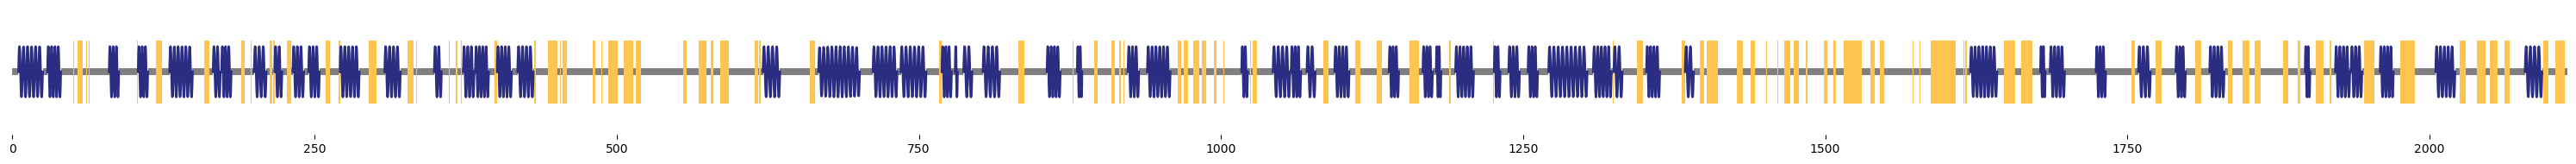

In [4]:
#This requires DSSP to run
# read more here: https://hpc.nih.gov/apps/DSSP.html
!module load DSSP

# Load the structure and plot the secondary structure
import os
import subprocess
PDB="./fold_drue3_wp_020219138_model_0.pdb"
pdb_file = pdb.PDBFile.read(PDB)
array = pdb.get_structure(pdb_file, model=1)

tmnECOR25 = array[struc.filter_amino_acids(array)]
#The trick here that without the complete path I get the Permission denied
sse = dssp.DsspApp.annotate_sse(tmnECOR25, bin_path="/usr/local/apps/DSSP/2.3.0/bin/mkdssp")
sse = np.array([dssp_to_abc[e] for e in sse], dtype="U1")
#get correctly formatted annotation
annotation = get_annotation(sse, tmnECOR25.res_id[0])

first_id = tmnECOR25.res_id[0]

fig = plt.figure(figsize=(30,2))
ax = fig.add_subplot(111)
graphics.plot_feature_map(
    ax,
    annotation,
    loc_range=(first_id, first_id + len(sse)),
    #show_numbers=True,
    show_line_position=True,
    symbols_per_line=len(sse),
    feature_plotters=[HelixPlotter(), SheetPlotter()],
)
fig.tight_layout()


In [5]:
import numpy as np
xvalues = np.arange(cons_scores.shape[0])

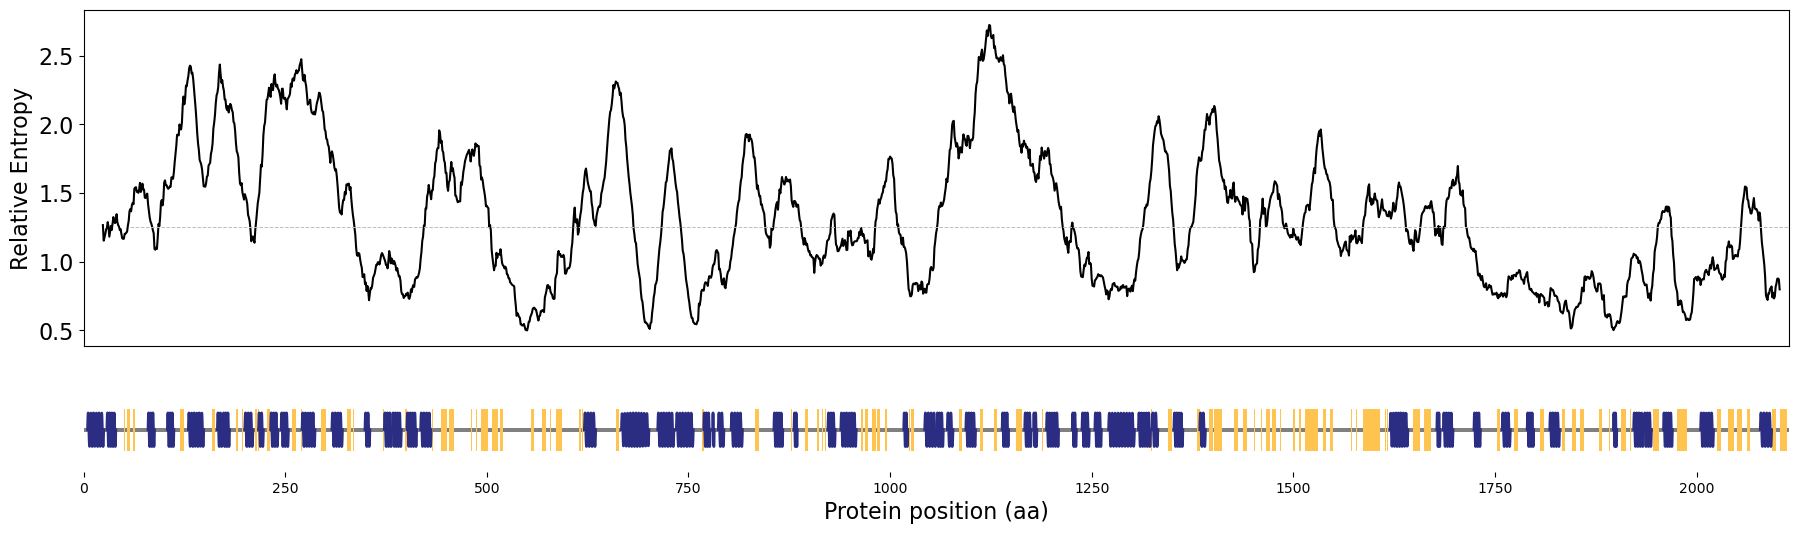

In [7]:
# Plot the outcomes
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

cons_rolling = cons_scores.rolling(window=25).mean()
#print(np.mean(cons_rolling))
#print(np.nanmedian(cons_rolling))

fig=plt.figure(figsize=(22,6))

gs = gridspec.GridSpec(2, 1,height_ratios=[4,1])

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])
#Plotting the mean of relative entropy in a sliding window of size 25
ax1.plot(xvalues, cons_rolling, c='black',lw=1.5)
ax1.axhline(y=np.nanmedian(cons_rolling), xmin=35/1273, xmax=1,color='#bdbdbd', linestyle='--',lw=.7)
ax1.set_ylabel("Relative Entropy")
ax1.xaxis.set_visible(False)
#ax1.annotate('NTPase domain',xy=(120, 2.0),fontsize=10, color = '#cc4c02')
#rect = patches.Rectangle((37,.6), 410, 1.8, linewidth=1, edgecolor='#cc4c02', facecolor='#a22762', alpha=.05, lw=.5)
#ax1.add_patch(rect)
#ax1.axhline(y=np.nanmedian(cons_rolling[0:409]), xmin=35/1273, xmax=448/1273,color='#a22762', linestyle='--',lw=1)
#ax1.axhline(y=np.nanmedian(cons_rolling[410:1273]), xmin=450/1273, xmax=1,color='#268c90', linestyle='--',lw=1)
plt.rc('ytick', labelsize=16)
plt.rc('axes', labelsize=16)
#Adding info on the secondary structure from tmn25
ax2.sharex(ax1)
ax2.set_xlabel("Protein position (aa)")
graphics.plot_feature_map(
    ax2,
    annotation,
    loc_range=(first_id, first_id + len(sse)),
    #show_numbers=True,
    show_line_position=True,
    symbols_per_line=len(sse),
    feature_plotters=[HelixPlotter(), SheetPlotter()],
)

fig.savefig("DruE3_relative_entropy_20250520.pdf")

In [8]:
###############Do the same for DruH
DruHcanal = Canal(fastafile='./DruH3_mmseqs98.MUSCLE5.faa', # Multiple sequence alignment (MSA) of homologous sequences
              ref=189, # Position of reference sequence in MSA, I use ECOR19 as before
              #startcount=-16, # Position label of first residue in reference sequence
              verbose=True # Print out progress
              )
# Compute conservation scores for each site in reference sequence with relative entropy method
DruH_cons_scores = DruHcanal.analysis(include=None, method='relative')


577 sequences in fasta file

Multiple sequence alignment has 4045 total positions

Reference sequence is WP_133301053.1 STY4851/ECs_5259 family protein [Escherichia coli]

Reference sequence has 1119 residues (sites) and the first residue is labeled as position 1

Reference sequence residues are labeled as M-1, L-2, V-3, K-4, T-5

Calculating amino acid frequencies...
Done.

Calculating conservation scores with relative method...
Done


[+] Loading DSSP 2.3.0 on cn0002 


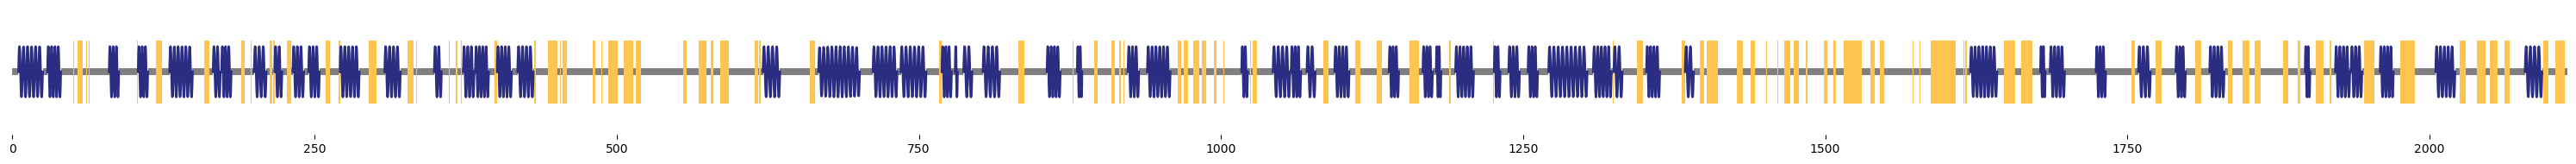

In [9]:
#This requires DSSP to run
# read more here: https://hpc.nih.gov/apps/DSSP.html
!module load DSSP

# Load the structure and plot the secondary structure
import os
import subprocess
DruHPDB="./fold_druh3_wp_213059564_model_0.pdb"
DruHpdb_file = pdb.PDBFile.read(DruHPDB)
DruHarray = pdb.get_structure(DruHpdb_file, model=1)

DruHECOR19 = DruHarray[struc.filter_amino_acids(DruHarray)]
#The trick here that without the complete path I get the Permission denied
DruHsse = dssp.DsspApp.annotate_sse(DruHECOR19, bin_path="/usr/local/apps/DSSP/2.3.0/bin/mkdssp")
DruHsse = np.array([dssp_to_abc[e] for e in DruHsse], dtype="U1")
#get correctly formatted annotation
DruHannotation = get_annotation(DruHsse, DruHECOR19.res_id[0])

DruHfirst_id = DruHECOR19.res_id[0]

DruHfig = plt.figure(figsize=(30,2))
ax = DruHfig.add_subplot(111)
graphics.plot_feature_map(
    ax,
    annotation,
    loc_range=(first_id, first_id + len(sse)),
    #show_numbers=True,
    show_line_position=True,
    symbols_per_line=len(sse),
    feature_plotters=[HelixPlotter(), SheetPlotter()],
)
DruHfig.tight_layout()

In [10]:
import numpy as np
DruHxvalues = np.arange(DruH_cons_scores.shape[0])

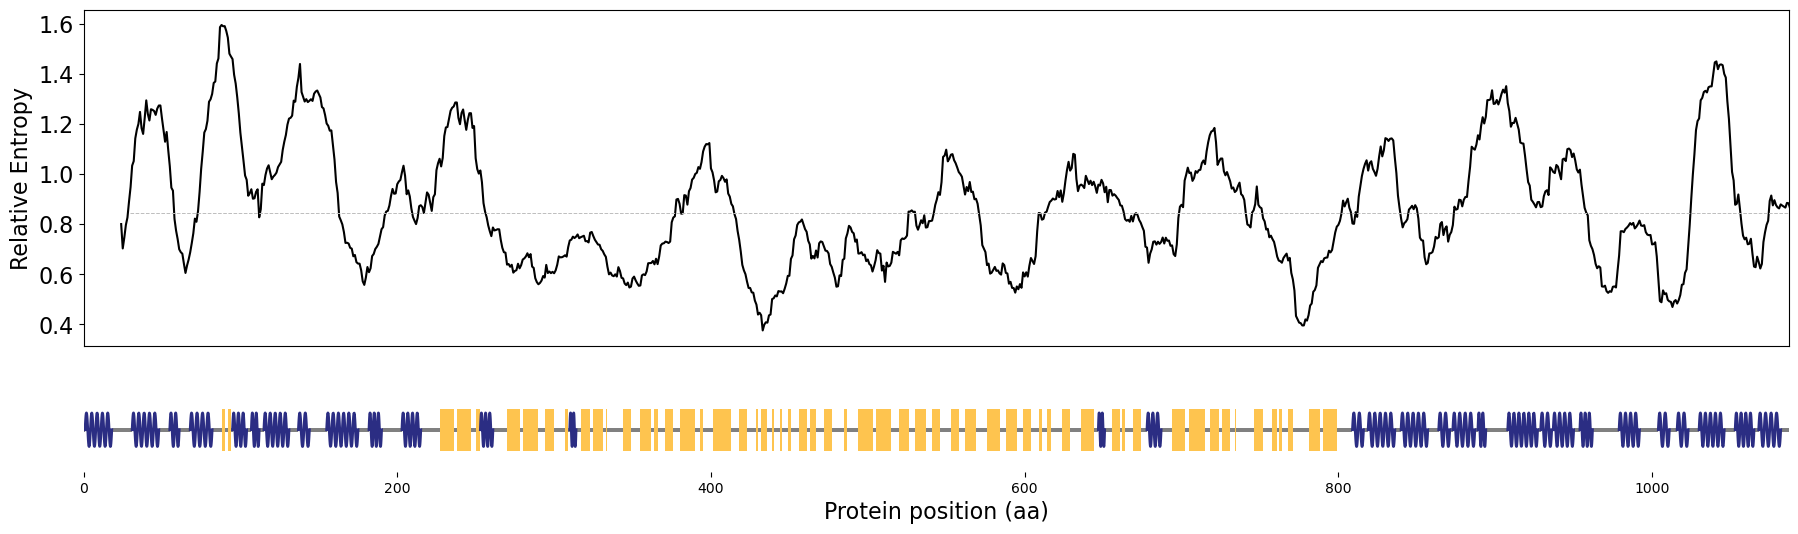

In [12]:
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

DruHcons_rolling = DruH_cons_scores.rolling(window=25).mean()
#print(np.mean(cons_rolling))
#print(np.nanmedian(cons_rolling))

fig=plt.figure(figsize=(22,6))

gs = gridspec.GridSpec(2, 1,height_ratios=[4,1])

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])
#Plotting the mean of relative entropy in a sliding window of size 25
ax1.plot(DruHxvalues, DruHcons_rolling, c='black',lw=1.5)
ax1.axhline(y=np.nanmedian(DruHcons_rolling), xmin=35/1273, xmax=1,color='#bdbdbd', linestyle='--',lw=.7)
ax1.set_ylabel("Relative Entropy")
ax1.xaxis.set_visible(False)
plt.rc('ytick', labelsize=16)
plt.rc('axes', labelsize=16)
#Adding info on the secondary structure from tmn25
ax2.sharex(ax1)
ax2.set_xlabel("Protein position (aa)")
graphics.plot_feature_map(
    ax2,
    DruHannotation,
    loc_range=(DruHfirst_id, DruHfirst_id + len(DruHsse)),
    #show_numbers=True,
    show_line_position=True,
    symbols_per_line=len(DruHsse),
    feature_plotters=[HelixPlotter(), SheetPlotter()],
)

fig.savefig("DruH3_relative_entropy_20250520.pdf")